- Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/btc_cleaned.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


- Data Cleaning

In [3]:
df = pd.read_csv(
    "../data/raw/btc_price.csv",
    skiprows=2
)

# Rename Columns
df.columns = [
    "Date",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2192 non-null   object 
 1   Close   2192 non-null   float64
 2   High    2192 non-null   float64
 3   Low     2192 non-null   float64
 4   Open    2192 non-null   float64
 5   Volume  2192 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 102.9+ KB


- Convert Data Types

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2192 non-null   datetime64[ns]
 1   Close   2192 non-null   float64       
 2   High    2192 non-null   float64       
 3   Low     2192 non-null   float64       
 4   Open    2192 non-null   float64       
 5   Volume  2192 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 102.9 KB


- Checking Missing Values

In [6]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [7]:
df = df.dropna()

df.shape

(2192, 6)

In [8]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


### Feature Engineering
- Create additional features that help in:

    - Trend Analysis
    - Volatility Analysis
    - Forecasting Models

In [9]:
# daily returns
df["Returns"] = df["Close"].pct_change()

df.head()
# Returns = (Today's Close - Yesterday's Close) / Yesterday's Close

,Date,Close,High,Low,Open,Volume,Returns
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,NaN
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-0.029819
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.051452
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.008955
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.000089


### Moving Avg help indentify trends
- MA7 → Short-term trend
- MA30 → Monthly trend
- MA50 → Medium-term trend
- MA200 → Long-term trend

In [10]:
# Moving Avg
df["MA7"] = df["Close"].rolling(window=7).mean()

df["MA30"] = df["Close"].rolling(window=30).mean()

df["MA50"] = df["Close"].rolling(window=50).mean()

df["MA200"] = df["Close"].rolling(window=200).mean()

df.head()

,Date,Close,High,Low,Open,Volume,Returns,MA7,MA30,MA50,MA200
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-0.029819,NaN,NaN,NaN,NaN
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.051452,NaN,NaN,NaN,NaN
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.008955,NaN,NaN,NaN,NaN
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.000089,NaN,NaN,NaN,NaN


### Volatility
- Measures risk and price fluctuations.

- Higher volatility = higher uncertainty.

In [11]:
# Volatility
df["Volatility"] = (
    df["Returns"]
    .rolling(window=30)
    .std()
)

df.head()

,Date,Close,High,Low,Open,Volume,Returns,MA7,MA30,MA50,MA200,Volatility
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-0.029819,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.051452,NaN,NaN,NaN,NaN,NaN
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.008955,NaN,NaN,NaN,NaN,NaN
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.000089,NaN,NaN,NaN,NaN,NaN


In [12]:
# Save Feature Engineered Dataset
df.to_csv(
    "../data/processed/btc_features.csv",
    index=False
)

print("Feature dataset saved successfully")

Feature dataset saved successfully


- Exploratory Data Analysis (EDA)

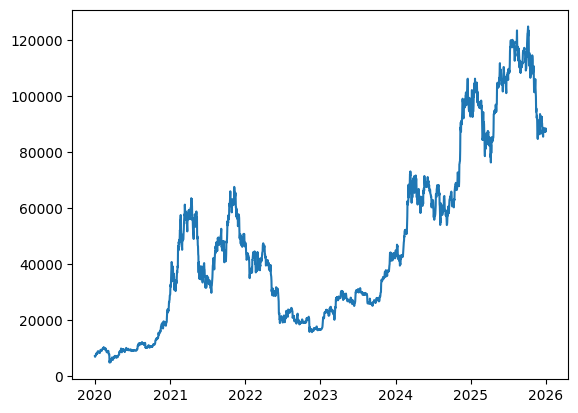

In [13]:
# closing price trend
plt.plot(df["Date"], df["Close"])

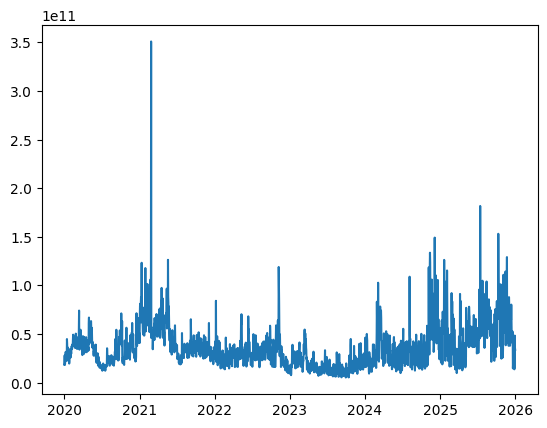

In [14]:
# Volume Trend
plt.plot(df["Date"], df["Volume"])

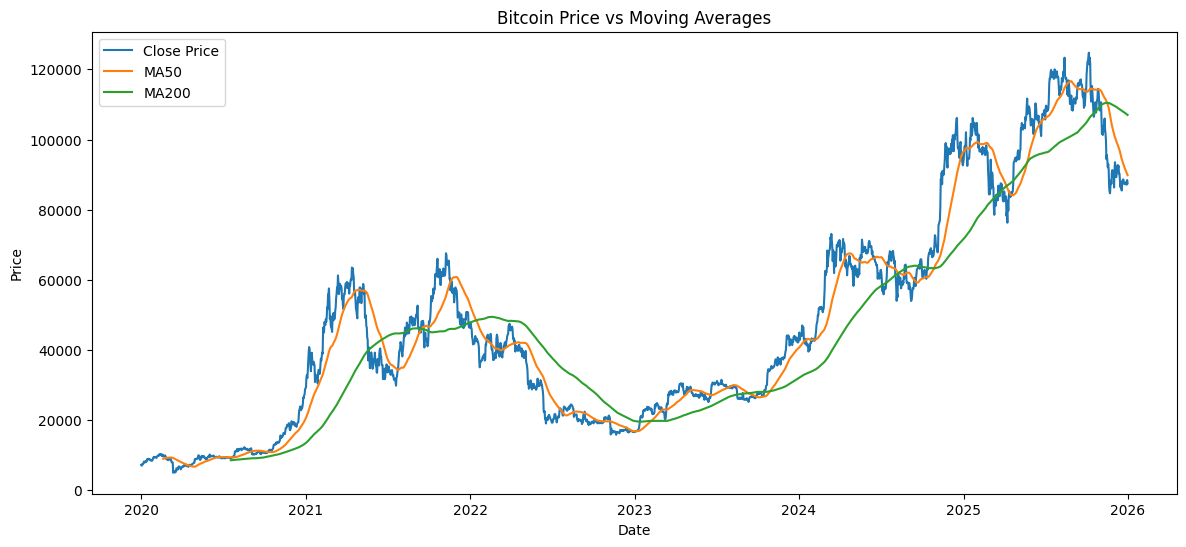

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")

plt.plot(df["Date"], df["MA50"], label="MA50")

plt.plot(df["Date"], df["MA200"], label="MA200")

plt.title("Bitcoin Price vs Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

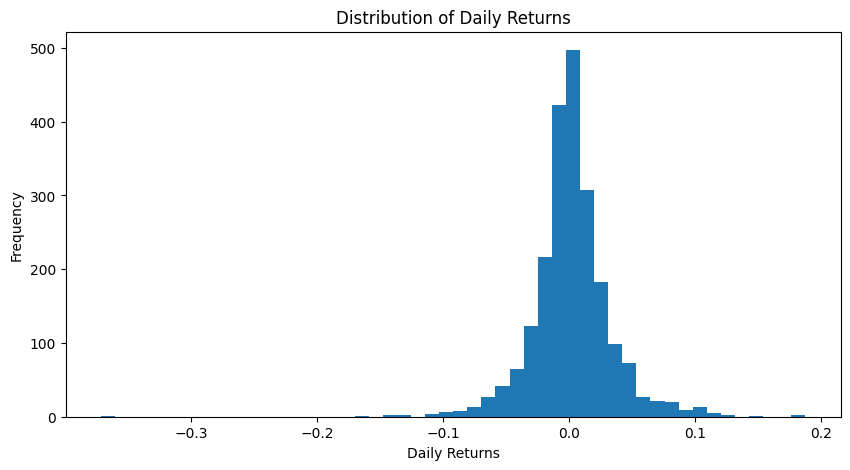

In [16]:
# Daily Returns Distribution
plt.figure(figsize=(10,5))

plt.hist(
    df["Returns"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Returns")

plt.ylabel("Frequency")

plt.show()

### Interpretation

- Most returns are concentrated around zero, indicating that small daily price changes are common.
- Extreme positive and negative returns occur less frequently, reflecting the volatile nature of cryptocurrency markets.

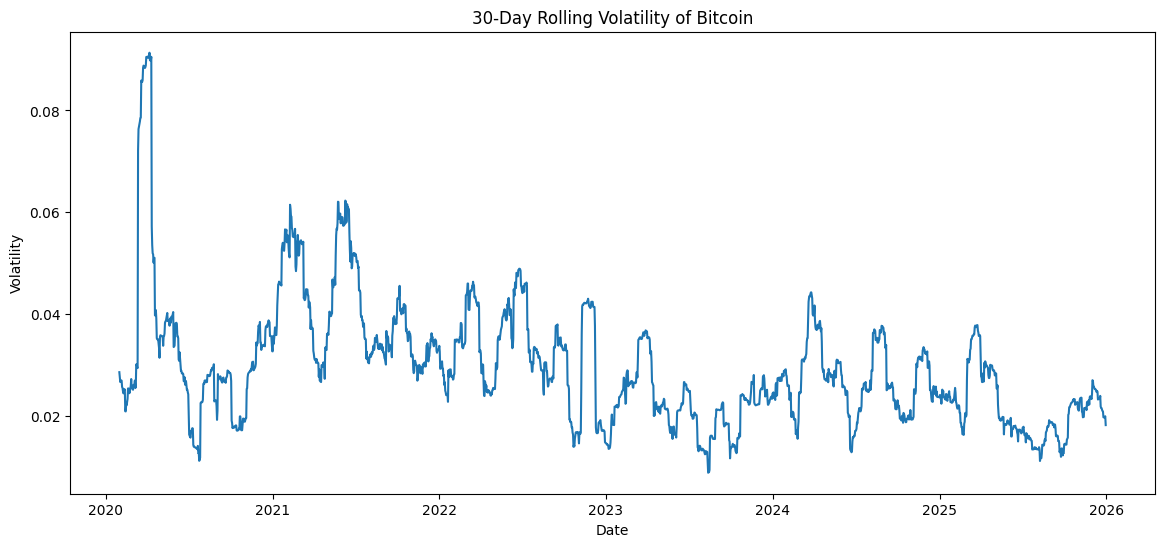

In [17]:
# Volatility Trend
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Volatility"]
)

plt.title("30-Day Rolling Volatility of Bitcoin")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.show()

### Interpretation

- Volatility measures the degree of variation in Bitcoin prices over time.
- Periods with high volatility indicate increased market uncertainty and larger price fluctuations.
- Lower volatility periods suggest more stable market behavior.

### Sentiment Analysis


In [18]:
news = pd.read_csv("../data/news/coindesk_news.csv")

news.head()

,Headline
0,SEC sues Texas man over $12.3 million alleged ...
1,SEC sues Texas man over $12.3 million alleged ...
2,U.S. says it seized about $1 billion in Irania...
3,Hyperliquid could become a ‘financial services...
4,"Bitcoin, ether, XRP, dogecoin lag a nine-week ..."


In [19]:
news.columns

Index(['Headline'], dtype='object')

In [20]:
#!pip install textblob

In [21]:
# Calculate Sentiment Score

from textblob import TextBlob
news["Sentiment_Score"] = news["Headline"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

news.head()

,Headline,Sentiment_Score
0,SEC sues Texas man over $12.3 million alleged ...,-0.233333
1,SEC sues Texas man over $12.3 million alleged ...,-0.233333
2,U.S. says it seized about $1 billion in Irania...,0.000000
3,Hyperliquid could become a ‘financial services...,0.000000
4,"Bitcoin, ether, XRP, dogecoin lag a nine-week ...",0.000000


In [22]:
# Create Sentiment Labels
def sentiment_label(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"


news["Sentiment_Label"] = news["Sentiment_Score"].apply(
    sentiment_label
)

news.head()

,Headline,Sentiment_Score,Sentiment_Label
0,SEC sues Texas man over $12.3 million alleged ...,-0.233333,Negative
1,SEC sues Texas man over $12.3 million alleged ...,-0.233333,Negative
2,U.S. says it seized about $1 billion in Irania...,0.000000,Neutral
3,Hyperliquid could become a ‘financial services...,0.000000,Neutral
4,"Bitcoin, ether, XRP, dogecoin lag a nine-week ...",0.000000,Neutral


In [23]:
#Count Sentiments
news["Sentiment_Label"].value_counts()

Sentiment_Label
Neutral     14
Positive     5
Negative     4
Name: count, dtype: int64

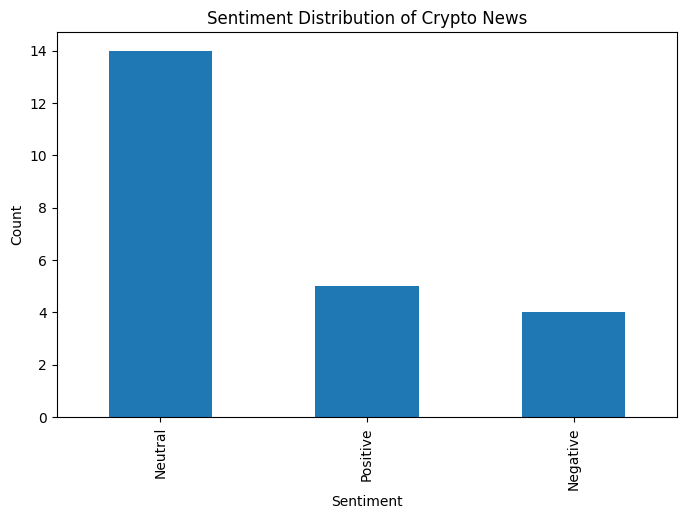

In [24]:
# Visualization
news["Sentiment_Label"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sentiment Distribution of Crypto News")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

# Interpretation
- Positive sentiment indicates optimistic market news
- negative sentiment reflects concerns or adverse events,
- and neutral sentiment represents factual or balanced reporting.

### ARIMA Forecasting

In [25]:
# !pip install statsmodels

In [26]:
# !pip install prophet

In [27]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [28]:
ts = df["Close"]

ts.head()

0    7200.174316
1    6985.470215
2    7344.884277
3    7410.656738
4    7411.317383
Name: Close, dtype: float64

Check Stationarity (ADF Test)
- The Augmented Dickey-Fuller test is used to check whether the time series is stationary.



In [29]:
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0576967833814759
p-value: 0.7316439023871095


### Train-Test Split

In [30]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]

test = ts[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 1753
Test Size: 439


In [31]:
# Build ARIMA Model
model = ARIMA(
    train,
    order=(5,1,0)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1753
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -14984.915
Date:                Mon, 01 Jun 2026   AIC                          29981.829
Time:                        00:21:08   BIC                          30014.640
Sample:                             0   HQIC                         29993.957
                               - 1753                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0496      0.018     -2.834      0.005      -0.084      -0.015
ar.L2          0.0256      0.018      1.401      0.161      -0.010       0.061
ar.L3          0.0128      0.018      0.699      0.4

In [32]:
# forecast
forecast = model_fit.forecast(
    steps=len(test)
)

forecast[:5]

1753    68435.554627
1754    68486.672705
1755    68497.105686
1756    68527.605092
1757    68538.523740
Name: predicted_mean, dtype: float64

In [33]:
# Evaluation
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 30896.624317283095
RMSE: 33437.33151462343


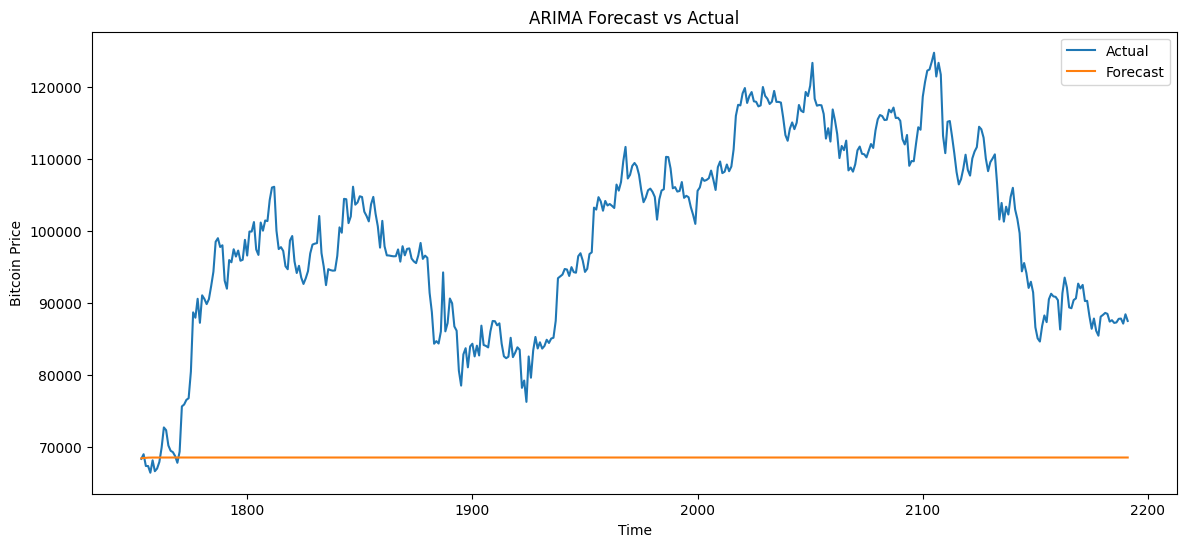

In [34]:
# Visualization
plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast"
)

plt.title("ARIMA Forecast vs Actual")

plt.xlabel("Time")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.show()

In [35]:
# Future Forecast
future_forecast = model_fit.forecast(
    steps=30
)

future_forecast

1753    68435.554627
1754    68486.672705
1755    68497.105686
1756    68527.605092
1757    68538.523740
1758    68540.672054
1759    68542.111590
1760    68543.298705
1761    68543.973675
1762    68544.173754
1763    68544.264362
1764    68544.326174
1765    68544.361844
1766    68544.376336
1767    68544.382305
1768    68544.385741
1769    68544.387688
1770    68544.388593
1771    68544.388984
1772    68544.389184
1773    68544.389294
1774    68544.389347
1775    68544.389372
1776    68544.389384
1777    68544.389390
1778    68544.389394
1779    68544.389395
1780    68544.389396
1781    68544.389396
1782    68544.389396
Name: predicted_mean, dtype: float64

In [36]:
print("MAE :", mae)
print("RMSE:", rmse)

MAE : 30896.624317283095
RMSE: 33437.33151462343


### Prophet forecasting

In [37]:
from prophet import Prophet
prophet_df = df[["Date", "Close"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

c:\Users\SNEHA\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ds,y
0,2020-01-01,7200.174316
1,2020-01-02,6985.470215
2,2020-01-03,7344.884277
3,2020-01-04,7410.656738
4,2020-01-05,7411.317383


In [38]:
# train-Test Split
train_size = int(len(prophet_df) * 0.8)

train = prophet_df[:train_size]

test = prophet_df[train_size:]

In [39]:
# build Prophet Model
model = Prophet()

model.fit(train)

00:21:09 - cmdstanpy - INFO - Chain [1] start processing
00:21:11 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
# forecast
future = model.make_future_dataframe(
    periods=len(test)
)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,5162.141424,-1151.788976,9245.192795,5162.141424,5162.141424,-1094.459019,-1094.459019,-1094.459019,62.458566,62.458566,62.458566,-1156.917585,-1156.917585,-1156.917585,0.0,0.0,0.0,4067.682405
1,2020-01-02,5125.858653,-1201.451565,8923.910627,5125.858653,5125.858653,-967.823898,-967.823898,-967.823898,-33.511915,-33.511915,-33.511915,-934.311983,-934.311983,-934.311983,0.0,0.0,0.0,4158.034755
2,2020-01-03,5089.575882,-922.872996,9681.290042,5089.575882,5089.575882,-754.922485,-754.922485,-754.922485,-24.877661,-24.877661,-24.877661,-730.044824,-730.044824,-730.044824,0.0,0.0,0.0,4334.653397
3,2020-01-04,5053.293110,-952.125117,9767.712178,5053.293110,5053.293110,-575.712836,-575.712836,-575.712836,-28.702020,-28.702020,-28.702020,-547.010815,-547.010815,-547.010815,0.0,0.0,0.0,4477.580275
4,2020-01-05,5017.010339,-448.156664,9546.173338,5017.010339,5017.010339,-410.499197,-410.499197,-410.499197,-22.840837,-22.840837,-22.840837,-387.658361,-387.658361,-387.658361,0.0,0.0,0.0,4606.511142


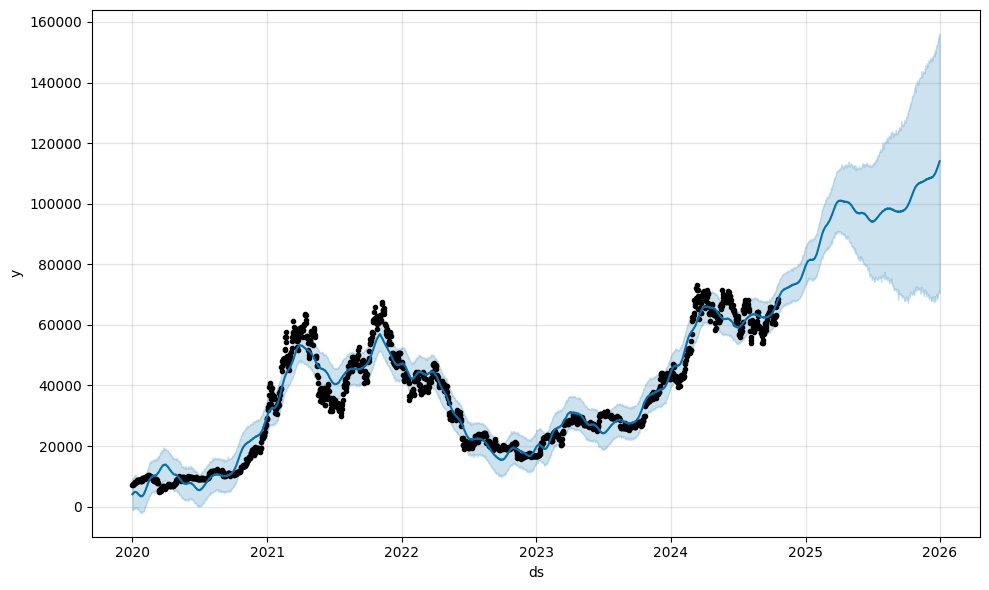

In [41]:
# forecast Visualisation
fig = model.plot(forecast)

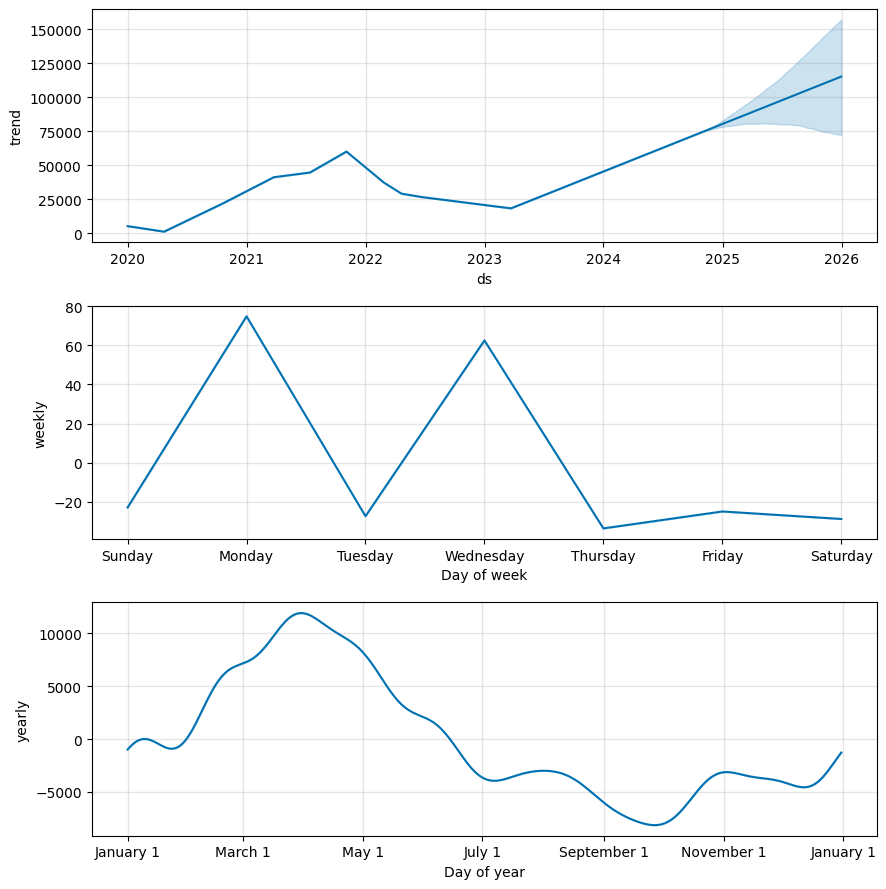

In [42]:
fig2 = model.plot_components(forecast)

In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
predictions = forecast["yhat"][-len(test):].values

In [44]:
mae_prophet = mean_absolute_error(
    test["y"],
    predictions
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions
    )
)

print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)

MAE : 14331.749544297067
RMSE: 15959.350771425901


In [45]:
# future 30 day Forecast
future_30 = model.make_future_dataframe(
    periods=30
)

future_forecast = model.predict(
    future_30
)

future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(30)

,ds,yhat,yhat_lower,yhat_upper
1753,2024-10-19,68545.081845,63809.556527,73475.452539
1754,2024-10-20,68861.839534,63321.721396,74137.634358
1755,2024-10-21,69259.953267,63810.229925,74618.817206
1756,2024-10-22,69446.105852,64086.903362,74931.399523
1757,2024-10-23,69810.028869,64582.633284,75431.303874
1758,2024-10-24,69972.779653,64892.906472,75177.229169
1759,2024-10-25,70223.531734,65050.454875,75724.689199
1760,2024-10-26,70444.389970,65329.605317,75745.991510
1761,2024-10-27,70656.994164,65729.516876,75961.195890
1762,2024-10-28,70943.226054,65699.437234,76116.269584


### LSTM Forecasting

In [46]:
arima_mae = mae
arima_rmse = rmse

print(arima_mae)
print(arima_rmse)

print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)

30896.624317283095
33437.33151462343
MAE : 14331.749544297067
RMSE: 15959.350771425901


In [47]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense
)

import numpy as np

c:\Users\SNEHA\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [48]:
# prepare data
lstm_df = df[["Close"]].copy()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    lstm_df
)

scaled_data[:5]

array([[0.01861207],
       [0.01681961],
       [0.01982018],
       [0.02036929],
       [0.0203748 ]])

In [49]:
# create Sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[
            i-sequence_length:i,
            0
        ]
    )

    y.append(
        scaled_data[i,0]
    )

X = np.array(X)

y = np.array(y)

X = np.reshape(
    X,
    (X.shape[0], X.shape[1], 1)
)

print(X.shape)
print(y.shape)

(2132, 60, 1)
(2132,)


In [50]:
# Train-Test Split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(1705, 60, 1)
(427, 60, 1)


In [51]:
# Build LSTM Model
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)

model.add(
    LSTM(50)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

c:\Users\SNEHA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Train
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0093 - val_loss: 0.0042
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.2858e-04 - val_loss: 0.0017
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 6.6025e-04 - val_loss: 0.0017
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 6.1958e-04 - val_loss: 0.0014
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 5.7962e-04 - val_loss: 0.0014
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 5.4964e-04 - val_loss: 0.0013
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 4.9610e-04 - val_loss: 0.0017
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 4.7332e-04 - val_loss: 0.0017
Epoch 9/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 4.7422e-04 - val_loss: 0.0010
Epoch 10/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 4.1651e-04 - val_loss: 0.0015


In [53]:
# Predict
predictions = model.predict(
    X_test
)

predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [54]:
# Evaluate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

lstm_mae = mean_absolute_error(
    actual,
    predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)

MAE : 3791.531780591335
RMSE: 4677.243344685481


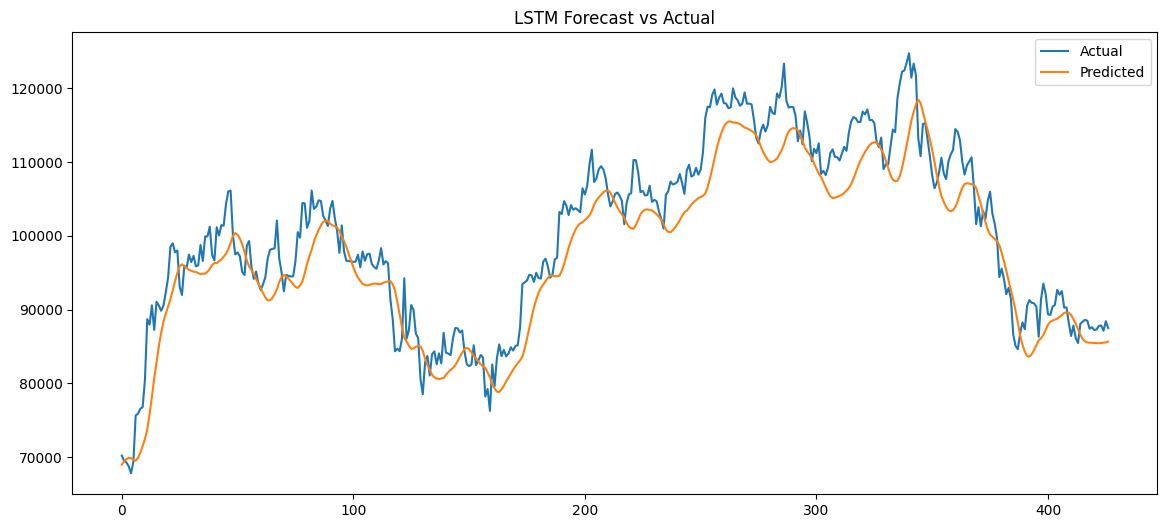

In [55]:
# plot
plt.figure(figsize=(14,6))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title(
    "LSTM Forecast vs Actual"
)

plt.legend()

plt.show()

### Model Comparision

In [56]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "LSTM"],
    "MAE": [
        arima_mae,
        mae_prophet,
        lstm_mae
    ],
    "RMSE": [
        arima_rmse,
        rmse_prophet,
        lstm_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,ARIMA,30896.624317,33437.331515
1,Prophet,14331.749544,15959.350771
2,LSTM,3791.531781,4677.243345


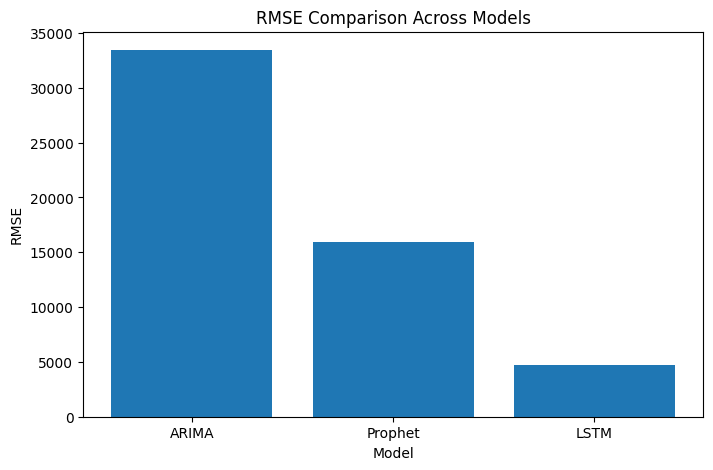

In [57]:
# Visaulisation
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("RMSE Comparison Across Models")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.show()

### Save the Models

In [58]:
import pickle

with open("../models/arima.pkl", "wb") as f:
    pickle.dump(model_fit, f)

In [59]:
from joblib import dump

dump(model, "../models/prophet.pkl")

['../models/prophet.pkl']

In [60]:
model.save("../models/lstm.keras")

In [61]:
model
prophet_model = Prophet()
lstm_model = Sequential()


#-------------------#